# Collapsing labels at load time — `LabelMap`

Some datasets annotate both an **object** and what it is **doing**. A mouse-behaviour dataset
might carry four classes:

| id | name | meaning |
|----|------|---------|
| 0 | `mouse` | a mouse |
| 1 | `feeding` | a mouse, eating |
| 2 | `climbing` | a mouse, climbing |
| 3 | `food` | the food hopper — *not* a mouse |

To train a plain mouse detector you want `feeding` and `climbing` to count as `mouse`, while
`food` stays exactly as it is. `LabelMap` does that **as the dataset is read**: no duplicated
dataset, no rewritten annotation files.

This notebook builds a small dataset from scratch and shows:

1. what the raw dataset looks like
2. the headline collapse, visually, before and after
3. that the files on disk are never touched
4. the options — `reindex`, `drop_unmapped`, `dedup_iou`
5. wiring the result into a datagenerator
6. the offline CLI, `saltup_collapse_labels`, and its safety guards
7. COCO and Pascal VOC, including the fields the loaders don't parse

Everything runs in a temporary directory that is removed in the last cell.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")   # quiet TensorFlow's start-up banner

import json
import logging
import shutil
import subprocess
import sys
import tempfile
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

from saltup.ai.base_dataformat.label_map import LabelMap
from saltup.ai.base_dataformat.base_dataloader import ColorMode
from saltup.ai.object_detection.dataset.yolo_darknet import (
    YoloDarknetLoader, create_dataset_structure,
)
from saltup.ai.object_detection.dataset.coco import COCOLoader
from saltup.ai.object_detection.dataset.pascal_voc import PascalVOCLoader
from saltup.ai.object_detection.dataset.loader_factory import DataLoaderFactory
from saltup.ai.object_detection.datagenerator.anchors_based_datagen import AnchorsBasedDatagen
from saltup.ai.object_detection.utils.bbox import BBoxFormat

# saltup logs every loader construction at INFO; quiet it so the output below is readable.
logging.getLogger().setLevel(logging.WARNING)

CLASS_NAMES = ["mouse", "feeding", "climbing", "food"]
COLORS = {0: "#4C9BE8", 1: "#E8A33D", 2: "#B45BD6", 3: "#5CB85C"}

WORK = Path(tempfile.mkdtemp(prefix="label_collapse_"))
print("working directory:", WORK)

SALTUP_BACKEND set to default mode 'keras_tensorflow'. Using TensorFlow as Keras backend.


E0000 00:00:1785161657.555908  116357 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785161657.559193  116357 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


working directory: /tmp/label_collapse_wbmx1g44


## 1. Build a sample dataset

Five images in YOLO Darknet format. The images are synthetic — grey blobs for mice, a brown
square for the food hopper — so that the boxes are actually worth looking at.

The samples are chosen to cover every case that matters:

* `cage01_0001` — a mouse **and** a `feeding` box on the *same animal* (IoU ≈ 0.97)
* `cage01_0002` — two separate mice, one climbing, plus food
* `cage02_0001` — **only** `food`, a class we will never map
* `cage02_0002` — a behaviour with no accompanying `mouse` box
* `cage03_0001` — all four classes, with `feeding` only partly over the mouse

In [2]:
SAMPLES = {
    "cage01_0001": [(0, 0.500, 0.500, 0.240, 0.180),
                    (1, 0.502, 0.498, 0.238, 0.182)],
    "cage01_0002": [(0, 0.250, 0.600, 0.200, 0.160),
                    (2, 0.760, 0.300, 0.180, 0.220),
                    (3, 0.900, 0.880, 0.120, 0.100)],
    "cage02_0001": [(3, 0.880, 0.900, 0.130, 0.110)],
    "cage02_0002": [(1, 0.400, 0.450, 0.220, 0.190)],
    "cage03_0001": [(0, 0.300, 0.500, 0.200, 0.200),
                    (1, 0.360, 0.540, 0.200, 0.200),
                    (2, 0.700, 0.250, 0.160, 0.240),
                    (3, 0.900, 0.900, 0.100, 0.100)],
}

SIZE = 256


def render_cage(boxes, size=SIZE):
    """Draw a fake cage: bedding background, a blob per mouse, a square for food."""
    img = np.full((size, size, 3), 210, np.uint8)
    rng = np.random.default_rng(0)
    speckle = rng.integers(0, 22, (size, size, 1)).astype(np.uint8)
    img = np.clip(img.astype(int) - speckle, 0, 255).astype(np.uint8)

    for class_id, xc, yc, w, h in boxes:
        cx, cy = int(xc * size), int(yc * size)
        bw, bh = int(w * size), int(h * size)
        if class_id == 3:                                   # food hopper
            cv2.rectangle(img, (cx - bw // 2, cy - bh // 2),
                          (cx + bw // 2, cy + bh // 2), (60, 90, 130), -1)
        elif class_id in (0, 1):                            # mouse body
            cv2.ellipse(img, (cx, cy), (bw // 2, bh // 2), 0, 0, 360, (120, 120, 125), -1)
            cv2.circle(img, (cx + bw // 3, cy), max(3, bh // 6), (90, 90, 95), -1)
        else:                                               # climbing mouse, upright
            cv2.ellipse(img, (cx, cy), (bw // 2, bh // 2), 75, 0, 360, (120, 120, 125), -1)
    return img


dataset = WORK / "mice"
dirs = create_dataset_structure(str(dataset))

for stem, boxes in SAMPLES.items():
    cv2.imwrite(f"{dirs['images']['train']}/{stem}.jpg", render_cage(boxes))
    lines = [f"{c} {x:.3f} {y:.3f} {w:.3f} {h:.3f}" for c, x, y, w, h in boxes]
    Path(f"{dirs['labels']['train']}/{stem}.txt").write_text("\n".join(lines) + "\n")

IMAGES = dirs["images"]["train"]
LABELS = dirs["labels"]["train"]
print(f"{len(SAMPLES)} images, {sum(len(v) for v in SAMPLES.values())} annotations")

5 images, 11 annotations


### The raw label files

YOLO Darknet labels are plain text: `class_id  x_centre  y_centre  width  height`, normalized.

In [3]:
for path in sorted(Path(LABELS).glob("*.txt")):
    print(path.name)
    for line in path.read_text().splitlines():
        print(f"    {line:<32}# {CLASS_NAMES[int(line.split()[0])]}")

cage01_0001.txt
    0 0.500 0.500 0.240 0.180       # mouse
    1 0.502 0.498 0.238 0.182       # feeding
cage01_0002.txt
    0 0.250 0.600 0.200 0.160       # mouse
    2 0.760 0.300 0.180 0.220       # climbing
    3 0.900 0.880 0.120 0.100       # food
cage02_0001.txt
    3 0.880 0.900 0.130 0.110       # food
cage02_0002.txt
    1 0.400 0.450 0.220 0.190       # feeding
cage03_0001.txt
    0 0.300 0.500 0.200 0.200       # mouse
    1 0.360 0.540 0.200 0.200       # feeding
    2 0.700 0.250 0.160 0.240       # climbing
    3 0.900 0.900 0.100 0.100       # food


### And what that looks like

Boxes are coloured by class. Note `cage01_0001`: the `mouse` and `feeding` boxes sit almost
exactly on top of each other, because they describe the same animal.

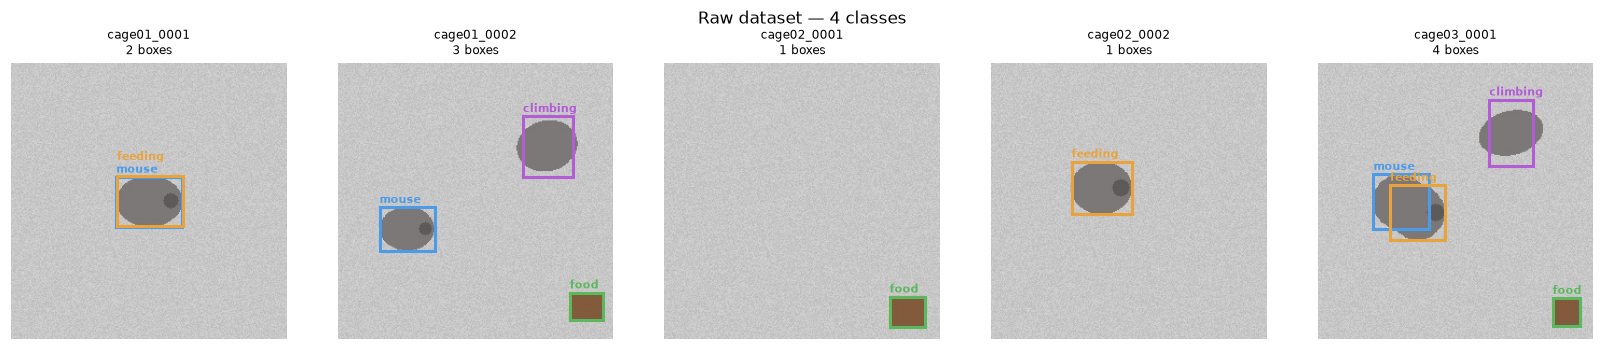

In [4]:
def draw(ax, image, annotations, title):
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    placed = []                       # keep labels of stacked boxes readable
    for box in annotations:
        xc, yc, w, h = box.get_coordinates(fmt=BBoxFormat.YOLO)
        x0, y0 = (xc - w / 2) * SIZE, (yc - h / 2) * SIZE
        colour = COLORS.get(box.class_id, "#888888")
        ax.add_patch(patches.Rectangle((x0, y0), w * SIZE, h * SIZE,
                                       fill=False, lw=2, edgecolor=colour))
        label = box.class_name or CLASS_NAMES[box.class_id]
        ty = y0 - 4
        while any(abs(ty - py) < 10 and abs(x0 - px) < 70 for px, py in placed):
            ty -= 11                  # nudge above the label already there
        placed.append((x0, ty))
        ax.text(x0, ty, label, color=colour, fontsize=7, weight="bold")
    ax.set_title(title, fontsize=8)
    ax.axis("off")


def show(loader, suptitle):
    items = sorted(loader, key=lambda item: Path(item[0]).stem)
    fig, axes = plt.subplots(1, len(items), figsize=(3 * len(items), 3.2))
    for ax, (path, image, annotations) in zip(np.atleast_1d(axes), items):
        draw(ax, image.get_data(), annotations,
             f"{Path(path).stem}\n{len(annotations)} boxes")
    fig.suptitle(suptitle, fontsize=11)
    fig.tight_layout()
    plt.show()


show(YoloDarknetLoader(IMAGES, LABELS), "Raw dataset — 4 classes")

## 2. Baseline: load with no label map

Nothing changes; this is the dataset as annotated. `get_label_map()` is `None`, and the whole
feature is inert for every existing caller.

In [5]:
def distribution(loader, names=CLASS_NAMES):
    counts = Counter()
    for _, _, annotations in loader:
        for box in annotations:
            counts[box.class_id] += 1
    return {names[c]: n for c, n in sorted(counts.items())}


baseline = YoloDarknetLoader(IMAGES, LABELS)
print("label map :", baseline.get_label_map())
print("classes   :", distribution(baseline))
print("total boxes:", sum(len(a) for _, _, a in baseline))

label map : None
classes   : {'mouse': 3, 'feeding': 3, 'climbing': 2, 'food': 3}
total boxes: 11


## 3. The collapse

`LabelMap.collapse` takes the labels to fold and the label to fold them into. Passing
`class_names` lets the rules be written by **name** even though YOLO annotations only carry
integer ids.

In [6]:
label_map = LabelMap.collapse(["feeding", "climbing"], into="mouse",
                              class_names=CLASS_NAMES)
collapsed = YoloDarknetLoader(IMAGES, LABELS, label_map=label_map)

print("rule          :", label_map.mapping)
print("original -> final:", label_map.get_class_mapping())
print()
print("before:", distribution(baseline))
print("after :", distribution(collapsed))
print()
print(f"boxes before {sum(len(a) for _, _, a in baseline)}, "
      f"after {sum(len(a) for _, _, a in collapsed)}  (pure relabelling)")

rule          : {'feeding': 'mouse', 'climbing': 'mouse'}
original -> final: {0: 0, 1: 0, 2: 0, 3: 3}

before: {'mouse': 3, 'feeding': 3, 'climbing': 2, 'food': 3}
after : {'mouse': 8, 'food': 3}

boxes before 11, after 11  (pure relabelling)


`feeding` and `climbing` became `mouse`; `food` was never mentioned, so it is untouched.
Notice the ids: `food` is still **3**, leaving a gap where 1 and 2 used to be. That is the
default — see `reindex` below.

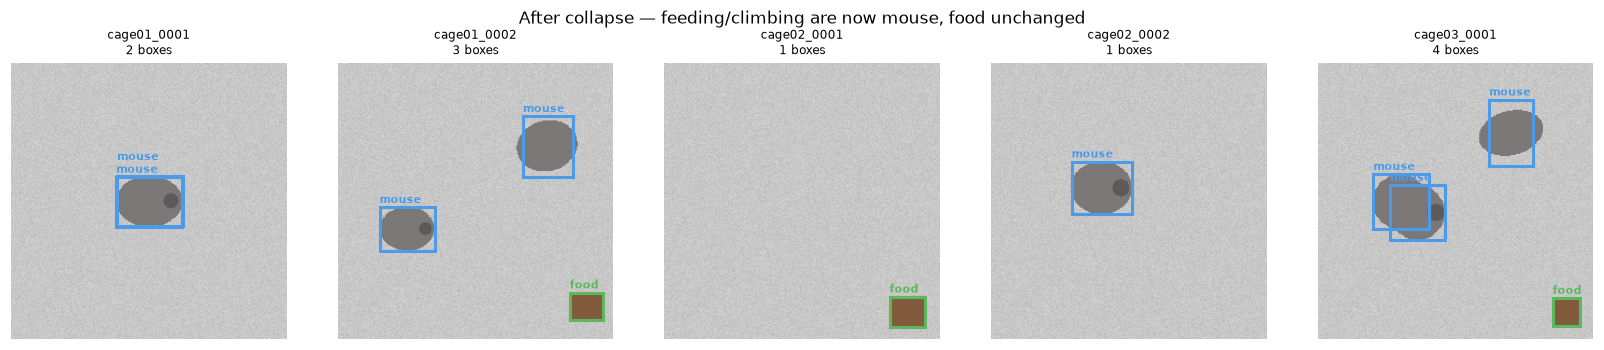

In [7]:
show(collapsed, "After collapse — feeding/climbing are now mouse, food unchanged")

### The files on disk are unchanged

This is the whole point: the mapping happens as the annotations are read.

In [8]:
on_disk = Path(f"{LABELS}/cage01_0001.txt").read_text()
print("cage01_0001.txt on disk:")
print(on_disk)
print("in memory via the loader:",
      [b.class_id for b in collapsed[0][2]])
assert [line.split()[0] for line in on_disk.splitlines()] == ["0", "1"]
print("\nOK — the file still says class 0 then class 1.")

cage01_0001.txt on disk:
0 0.500 0.500 0.240 0.180
1 0.502 0.498 0.238 0.182

in memory via the loader: [0, 0, 0, 3]

OK — the file still says class 0 then class 1.


### Two invariants worth checking

Reading the same item twice must give the same answer (the mapping must not compound), and
applying a map must never mutate the annotations a loader is holding. COCO caches its
annotation objects, so a mutating implementation would corrupt them on the second read.

In [9]:
first  = [b.class_id for _, _, a in collapsed for b in a]
second = [b.class_id for _, _, a in collapsed for b in a]
print("read twice, identical:", first == second)

fresh = YoloDarknetLoader(IMAGES, LABELS)
before = [b.class_id for _, _, a in fresh for b in a]
label_map.apply(fresh[0][2])                      # apply directly to its annotations
after = [b.class_id for _, _, a in fresh for b in a]
print("loader's own annotations untouched by apply():", before == after)
print("  still:", before)

read twice, identical: True
loader's own annotations untouched by apply(): True
  still: [0, 1, 2, 3, 1, 3, 0, 2, 3, 0, 1]


## 4. `reindex` — contiguous ids for training

Collapsing leaves a hole: `{0, 3}`. A datagenerator allocates `5 + num_classes` and indexes it
by `class_id`, so the gap breaks training. `reindex=True` renumbers what survives.

> This is the one option that silently changes ids relative to an external class list or a
> trained checkpoint, which is why it is **off by default**. Print `get_class_mapping()` and
> keep it with the run.

In [10]:
reindexed = LabelMap.collapse(["feeding", "climbing"], into="mouse",
                              class_names=CLASS_NAMES, reindex=True)
loader_r = YoloDarknetLoader(IMAGES, LABELS, label_map=reindexed)

print("original -> final:", reindexed.get_class_mapping())
print("surviving classes:", reindexed.get_class_names())
print("num_classes      :", reindexed.get_num_classes())
print("ids seen         :", sorted({b.class_id for _, _, a in loader_r for b in a}))

original -> final: {0: 0, 1: 0, 2: 0, 3: 1}
surviving classes: ['mouse', 'food']
num_classes      : 2
ids seen         : [0, 1]


## 5. `drop_unmapped` — keep only the mouse family

Discard anything not named in the mapping. The **destination** class is always kept, so
collapsing `feeding` into `mouse` never throws `mouse` away.

In [11]:
dropping = LabelMap.collapse(["feeding", "climbing"], into="mouse",
                             class_names=CLASS_NAMES, drop_unmapped=True)
loader_d = YoloDarknetLoader(IMAGES, LABELS, label_map=dropping)

print("classes:", distribution(loader_d))
for path, _, annotations in sorted(loader_d, key=lambda i: Path(i[0]).stem):
    print(f"  {Path(path).stem}: {len(annotations)} boxes")
print("\ncage02_0001 held only food, so it now has none.")

classes: {'mouse': 8}
  cage01_0001: 2 boxes
  cage01_0002: 2 boxes
  cage02_0001: 0 boxes
  cage02_0002: 1 boxes
  cage03_0001: 3 boxes

cage02_0001 held only food, so it now has none.


## 6. `dedup_iou` — merge the duplicate box

Collapsing `mouse` + `feeding` on the same animal leaves two nearly identical `mouse` boxes.
Often that is exactly what the annotation meant, so **nothing is dropped by default**. When you
do want them merged, give an IoU threshold.

Below, `cage01_0001` (IoU ≈ 0.97) collapses to one box, while `cage03_0001` — where `feeding`
only partly overlaps the mouse — keeps both.

In [12]:
deduped = LabelMap.collapse(["feeding", "climbing"], into="mouse",
                            class_names=CLASS_NAMES, dedup_iou=0.9)
loader_x = YoloDarknetLoader(IMAGES, LABELS, label_map=deduped)

print(f"{'file':<14}{'collapsed':>11}{'deduped':>10}")
for (path, _, a_plain), (_, _, a_dedup) in zip(
        sorted(collapsed, key=lambda i: Path(i[0]).stem),
        sorted(loader_x,  key=lambda i: Path(i[0]).stem)):
    print(f"{Path(path).stem:<14}{len(a_plain):>11}{len(a_dedup):>10}")

file            collapsed   deduped
cage01_0001             2         1
cage01_0002             3         3
cage02_0001             1         1
cage02_0002             1         1
cage03_0001             4         4


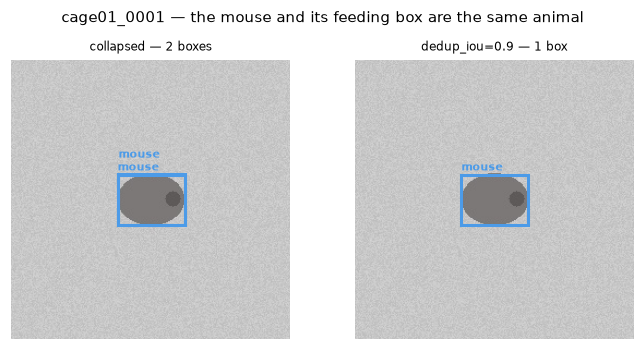

In [13]:
pick = lambda loader, stem: next(i for i in loader if Path(i[0]).stem == stem)
fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.2))
for ax, (lbl, ldr) in zip(axes, [("collapsed — 2 boxes", collapsed),
                                 ("dedup_iou=0.9 — 1 box", loader_x)]):
    path, image, annotations = pick(ldr, "cage01_0001")
    draw(ax, image.get_data(), annotations, lbl)
fig.suptitle("cage01_0001 — the mouse and its feeding box are the same animal", fontsize=10)
fig.tight_layout()
plt.show()

## 7. Attaching a map later, and the factory

A map can be set after construction, and `DataLoaderFactory` forwards `label_map=` to whichever
format it detects — YOLO, COCO or Pascal VOC.

In [14]:
late = YoloDarknetLoader(IMAGES, LABELS)
late.set_label_map(LabelMap.collapse([1, 2], into=0))     # by id — no class_names needed
print("set_label_map:", distribution(late))

train, val, test = DataLoaderFactory.create(dataset, label_map=label_map)
print("factory      :", distribution(train))
print("val / test   :", val, test)

set_label_map: {'mouse': 8, 'food': 3}
Detecting dataset format in: /tmp/label_collapse_wbmx1g44/mice
Detected YOLO Darknet dataset format.
Creating YOLO train dataloader: /tmp/label_collapse_wbmx1g44/mice/images/train, /tmp/label_collapse_wbmx1g44/mice/labels/train
factory      : {'mouse': 8, 'food': 3}
val / test   : None None


## 8. Feeding a datagenerator

`num_classes` must match what survived, and the ids must be contiguous — so this is the case
for `reindex=True`. The label tensor's last axis should come out as `5 + num_classes`.

In [15]:
gen_loader = YoloDarknetLoader(IMAGES, LABELS, color_mode=ColorMode.GRAY,
                               label_map=reindexed)
datagen = AnchorsBasedDatagen(
    dataloader=gen_loader,
    anchors=np.array([[0.08, 0.08], [0.25, 0.25]]),
    target_size=(64, 64),
    grid_size=(4, 4),
    num_classes=reindexed.get_num_classes(),
    batch_size=2,
)
images, labels = datagen[0]
print("num_classes :", reindexed.get_num_classes())
print("images      :", images.shape)
print("labels      :", labels.shape, " -> last axis is 5 +", reindexed.get_num_classes())
assert labels.shape[-1] == 5 + reindexed.get_num_classes()

num_classes : 2
images      : (2, 64, 64, 1)
labels      : (2, 4, 4, 2, 7)  -> last axis is 5 + 2


## 9. The CLI — `saltup_collapse_labels`

For a permanent copy there is an offline counterpart. It **copies** the dataset and rewrites
annotations in the copy; the input is never modified.

In [16]:
def cli(*args):
    proc = subprocess.run([sys.executable, "-m", "saltup.tools.collapse_labels", *args],
                          capture_output=True, text=True)
    for line in proc.stdout.splitlines():
        if "SALTUP_BACKEND" not in line:
            print(line)
    if proc.stderr.strip():
        print("stderr:", proc.stderr.strip().splitlines()[-1])
    return proc.returncode


out = WORK / "mice_collapsed"
cli(str(dataset), str(out), "--map", "feeding=mouse", "climbing=mouse",
    "--class-names", *CLASS_NAMES)

Rules: {'feeding': 'mouse', 'climbing': 'mouse'}
Class mapping: {0: 0, 1: 0, 2: 0, 3: 3}
Detected YOLO dataset, copying /tmp/label_collapse_wbmx1g44/mice -> /tmp/label_collapse_wbmx1g44/mice_collapsed
Done: 4 files modified, 0 annotations dropped


0

In [17]:
print(f"{'':<14}{'input':<22}{'output':<22}")
for path in sorted(Path(LABELS).glob("*.txt")):
    src = path.read_text().split()[0::5]
    dst = (Path(out) / "labels" / "train" / path.name).read_text().split()[0::5]
    print(f"{path.stem:<14}{str(src):<22}{str(dst):<22}")
print("\ninput dataset unchanged:",
      Path(f"{LABELS}/cage01_0001.txt").read_text().split()[0::5] == ["0", "1"])

              input                 output                
cage01_0001   ['0', '1']            ['0', '0']            
cage01_0002   ['0', '2', '3']       ['0', '0', '3']       
cage02_0001   ['3']                 ['3']                 
cage02_0002   ['1']                 ['0']                 
cage03_0001   ['0', '1', '2', '3']  ['0', '0', '0', '3']  

input dataset unchanged: True


### Coordinates are preserved exactly

Only the class-id field is rewritten, so no precision is lost to a parse/format round trip.

In [18]:
print("input :", repr(Path(f"{LABELS}/cage01_0001.txt").read_text().splitlines()[1]))
print("output:", repr((Path(out) / "labels/train/cage01_0001.txt").read_text().splitlines()[1]))

input : '1 0.502 0.498 0.238 0.182'
output: '0 0.502 0.498 0.238 0.182'


### Safety guards

The tool refuses anything that could damage the source, and refuses to clobber without
`--force`.

In [19]:
guards = [
    ("output == input",        [str(dataset), str(dataset)]),
    ("output inside input",    [str(dataset), str(dataset / "sub")]),
    ("output not empty",       [str(dataset), str(out)]),
    ("malformed --map",        [str(dataset), str(WORK / "x"), "--map", "feeding"]),
]
for label, args in guards:
    argv = args if "--map" in args else args + ["--map", "1=0"]
    proc = subprocess.run([sys.executable, "-m", "saltup.tools.collapse_labels", *argv],
                          capture_output=True, text=True)
    message = next((l for l in proc.stderr.splitlines() if l.startswith("Error:")), "")
    print(f"[exit {proc.returncode}] {label:<20} {message[:78]}")

[exit 1] output == input      Error: output_dir must differ from input_dir: /tmp/label_collapse_wbmx1g44/mic
[exit 1] output inside input  Error: output_dir /tmp/label_collapse_wbmx1g44/mice/sub is inside input_dir /t
[exit 1] output not empty     Error: output_dir /tmp/label_collapse_wbmx1g44/mice_collapsed already exists a
[exit 1] malformed --map      Error: invalid --map entry 'feeding', expected 'source=destination'


## 10. COCO and Pascal VOC

The CLI rewrites annotations **in their original container** — the COCO json dict, the VOC XML
tree — so fields the loaders never parse survive untouched. That matters: a naive round trip
through the loaders would quietly drop segmentation masks.

In [20]:
coco_root = WORK / "coco_mice"
(coco_root / "images/train").mkdir(parents=True)
(coco_root / "annotations").mkdir()
cv2.imwrite(str(coco_root / "images/train/cage01.jpg"), render_cage(SAMPLES["cage01_0001"]))

source = {
    "info": {"description": "mouse behaviour study", "year": 2026},
    "licenses": [{"id": 1, "name": "CC-BY-4.0"}],
    "images": [{"id": 1, "file_name": "cage01.jpg", "width": SIZE, "height": SIZE}],
    # Sparse, non-zero-based category ids — legal COCO, and the awkward case.
    "categories": [{"id": 1, "name": "mouse", "supercategory": "animal"},
                   {"id": 4, "name": "feeding", "supercategory": "behaviour"},
                   {"id": 9, "name": "food", "supercategory": "object"}],
    "annotations": [
        {"id": 1, "image_id": 1, "category_id": 1, "bbox": [10, 10, 20, 15],
         "area": 300, "iscrowd": 0, "segmentation": [[10, 10, 30, 10, 30, 25]]},
        {"id": 2, "image_id": 1, "category_id": 4, "bbox": [10, 10, 20, 15],
         "area": 300, "iscrowd": 0, "segmentation": [[10, 10, 30, 10, 30, 25]]},
        {"id": 3, "image_id": 1, "category_id": 9, "bbox": [50, 50, 8, 8],
         "area": 64, "iscrowd": 1, "segmentation": []},
    ],
}
(coco_root / "annotations/instances_train.json").write_text(json.dumps(source, indent=2))

cli(str(coco_root), str(WORK / "coco_out"), "--map", "feeding=mouse")

result = json.loads((WORK / "coco_out/annotations/instances_train.json").read_text())
print("\ncategories :", [(c["id"], c["name"]) for c in result["categories"]])
print("category_id:", [a["category_id"] for a in result["annotations"]])
print("segmentation survived:", result["annotations"][1]["segmentation"])
print("iscrowd / area       :", [(a["iscrowd"], a["area"]) for a in result["annotations"]])
print("info / licenses      :", result["info"], result["licenses"])

Rules: {'feeding': 'mouse'}
Detected COCO dataset, copying /tmp/label_collapse_wbmx1g44/coco_mice -> /tmp/label_collapse_wbmx1g44/coco_out
Resulting categories: [(1, 'mouse'), (9, 'food')]
Done: 1 annotations modified, 0 annotations dropped

categories : [(1, 'mouse'), (9, 'food')]
category_id: [1, 1, 9]
segmentation survived: [[10, 10, 30, 10, 30, 25]]
iscrowd / area       : [(0, 300), (0, 300), (1, 64)]
info / licenses      : {'description': 'mouse behaviour study', 'year': 2026} [{'id': 1, 'name': 'CC-BY-4.0'}]


COCO category ids are arbitrary and need not start at 0, so a plain list indexed by id does not
fit. Pass the dataset's own categories instead — `COCOLoader.get_category_names()` returns them
as `{id: name}`, which `class_names` accepts directly.

In [21]:
images_dir = coco_root / "images/train"
ann_file = coco_root / "annotations/instances_train.json"

base_coco = COCOLoader(images_dir, ann_file)
print("categories:", base_coco.get_category_names())

coco_map = LabelMap.collapse(["feeding"], into="mouse",
                             class_names=base_coco.get_category_names())
mapped_coco = COCOLoader(images_dir, ann_file, label_map=coco_map)
print("before:", [b.class_id for b in base_coco[0][2]])
print("after :", [b.class_id for b in mapped_coco[0][2]], " (agrees with the CLI output)")

categories: {1: 'mouse', 4: 'feeding', 9: 'food'}
before: [1, 4, 9]
after : [1, 1, 9]  (agrees with the CLI output)


### Pascal VOC

Both layouts are recognized: this project's `images/<split>` + `annotations/<split>`, and the
canonical `JPEGImages/` + `Annotations/` shipped in VOCdevkit. The one below is canonical.

`<pose>`, `<truncated>` and `<difficult>` are not parsed by the loader, and must survive.

In [22]:
voc_root = WORK / "voc_mice"
(voc_root / "JPEGImages").mkdir(parents=True)
(voc_root / "Annotations").mkdir()
cv2.imwrite(str(voc_root / "JPEGImages/cage01.jpg"), render_cage(SAMPLES["cage01_0001"]))
(voc_root / "Annotations/cage01.xml").write_text("""<annotation>
  <filename>cage01.jpg</filename>
  <size><width>256</width><height>256</height><depth>3</depth></size>
  <object><name>mouse</name><pose>Unspecified</pose><truncated>0</truncated><difficult>0</difficult>
    <bndbox><xmin>96</xmin><ymin>105</ymin><xmax>158</xmax><ymax>151</ymax></bndbox></object>
  <object><name>feeding</name><pose>Left</pose><truncated>1</truncated><difficult>1</difficult>
    <bndbox><xmin>97</xmin><ymin>104</ymin><xmax>159</xmax><ymax>152</ymax></bndbox></object>
  <object><name>food</name><pose>Rear</pose><truncated>0</truncated><difficult>0</difficult>
    <bndbox><xmin>210</xmin><ymin>216</ymin><xmax>240</xmax><ymax>246</ymax></bndbox></object>
</annotation>""")

cli(str(voc_root), str(WORK / "voc_out"), "--map", "feeding=mouse")

root = ET.parse(WORK / "voc_out/Annotations/cage01.xml").getroot()
objects = root.findall("object")
print("\nnames     :", [o.findtext("name") for o in objects])
print("pose      :", [o.findtext("pose") for o in objects])
print("truncated :", [o.findtext("truncated") for o in objects])
print("difficult :", [o.findtext("difficult") for o in objects])

Rules: {'feeding': 'mouse'}
Class mapping: {'feeding': 'mouse'}
Detected VOC dataset, copying /tmp/label_collapse_wbmx1g44/voc_mice -> /tmp/label_collapse_wbmx1g44/voc_out
Done: 1 files modified, 0 annotations dropped

names     : ['mouse', 'mouse', 'food']
pose      : ['Unspecified', 'Left', 'Rear']
truncated : ['0', '1', '0']
difficult : ['0', '1', '0']


VOC annotations are identified by **name**, and carry no class id at all (`class_id is None`).
A `LabelMap` matches on whichever of id/name an annotation provides, and writes back the same
way — so a VOC dataset stays name-based and a YOLO one stays id-based.

In [23]:
voc_map = LabelMap.collapse(["feeding"], into="mouse")
voc_before = PascalVOCLoader(voc_root / "JPEGImages", voc_root / "Annotations")
voc_after = PascalVOCLoader(voc_root / "JPEGImages", voc_root / "Annotations",
                            label_map=voc_map)

print("before:", [(b.class_id, b.class_name) for b in voc_before[0][2]])
print("after :", [(b.class_id, b.class_name) for b in voc_after[0][2]])

before: [(None, 'mouse'), (None, 'feeding'), (None, 'food')]
after : [(None, 'mouse'), (None, 'mouse'), (None, 'food')]


## Summary

| | |
|---|---|
| `LabelMap.collapse([...], into=...)` | fold labels into another label as the dataset is read |
| rules by id **or** name | `class_names` bridges the two; accepts a list or `{id: name}` |
| unmapped labels | passed through unchanged, unless `drop_unmapped=True` |
| `reindex=True` | renumber survivors contiguously for a datagenerator |
| `dedup_iou=x` | merge boxes that collapsed onto the same object |
| `label_map=` | accepted by all six loaders and by `DataLoaderFactory` |
| `saltup_collapse_labels` | writes a collapsed **copy**, preserving unparsed fields |

Guarantees demonstrated above: the source dataset is never modified, repeated reads are stable,
`apply()` does not mutate the loader's annotations, and each format keeps its own way of naming
a class.

Full reference: [`docs/label_mapping.md`](../../docs/label_mapping.md).

In [24]:
shutil.rmtree(WORK, ignore_errors=True)
print("removed", WORK)

removed /tmp/label_collapse_wbmx1g44
